In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Original Sources')

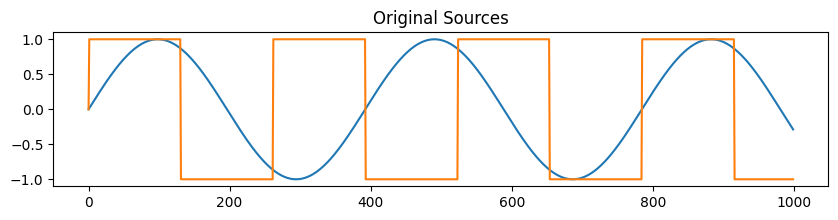

In [2]:
# Step 1: Generate sample signals
t = np.linspace(0, 8, 1000)
s1 = np.sin(2 * t)  # First independent source
s2 = np.sign(np.sin(3 * t))  # Second independent source (square wave)
S = np.c_[s1, s2]  # Combine the sources into a matrix

plt.figure(figsize=(10, 2))
plt.plot(S)
plt.title("Original Sources")

Text(0.5, 1.0, 'Mixed Signals')

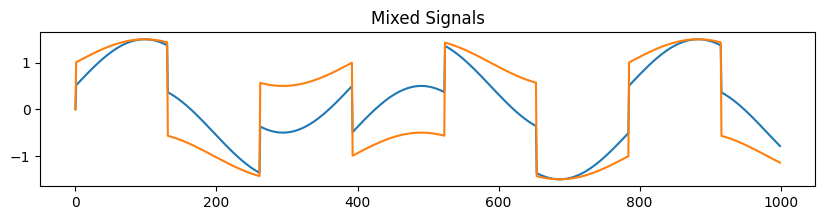

In [3]:
# Step 2: Mix the signals
A = np.array([[1, 0.5], [0.5, 1]])  # Mixing matrix
X = S @ A.T  # Mixed signals (observed signals)

plt.figure(figsize=(10, 2))
plt.plot(X)
plt.title("Mixed Signals")

Text(0.5, 1.0, 'Mixed Signals centered')

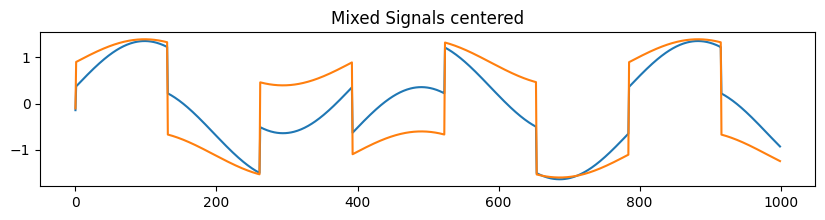

In [4]:
# Step 3: Center the data (zero mean)
X -= X.mean(axis=0)

plt.figure(figsize=(10, 2))
plt.plot(X)
plt.title("Mixed Signals centered")



In [5]:
# Step 4: Whitening using Eigenvalue Decomposition
covX = np.cov(X.T)  # Compute covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(covX)  # Eigen decomposition
D_inv = np.diag(1.0 / np.sqrt(eigenvalues))  # Inverse square root of eigenvalues
WhiteningMatrix = eigenvectors @ D_inv @ eigenvectors.T  # Whitening matrix
X_white = X @ WhiteningMatrix.T  # Apply whitening

In [6]:
for _ in range(100):  # Max 100 iterations
    WX = X_white @ W.T  # Compute projections
    g = np.tanh(WX)  # Non-linearity (approximate negentropy)
    g_deriv = 1 - g**2  # Derivative of tanh
    W_new = (g.T @ X_white) / X_white.shape[0] - np.diag(g_deriv.mean(axis=0)) @ W  # Update rule

    # Symmetric decorrelation (orthonormalization)
    W_new = np.linalg.svd(W_new)[0] @ np.linalg.svd(W_new)[2]  # Ensure orthogonality

    # Check for convergence
    if np.max(np.abs(np.abs(np.diag(W_new @ W.T)) - 1)) < 1e-6:
        break

    W = W_new  # Update weights

# Step 6: Recover independent sources
S_est = X_white @ W.T  # Estimated independent components

NameError: name 'W' is not defined

In [ ]:
# Step 7: Plot results
plt.figure(figsize=(10, 5))
plt.subplot(3, 1, 1)
plt.plot(S)
plt.title("Original Sources")

plt.subplot(3, 1, 2)
plt.plot(X)
plt.title("Mixed Signals")

plt.subplot(3, 1, 3)
plt.plot(S_est)
plt.title("Recovered Sources (ICA)")

plt.tight_layout()
plt.show()